# Part 2 — Piecewise Regression

## Part A: Baseline (Workflow2 in part 2.2 of project 1)

### A.1 — Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)
from scipy.spatial.distance import cdist

np.random.seed(23)
random_state = 23
print('Setup done.')

Setup done.


### A.2 — Load & Preprocess (same as proj1/part2-2)

In [2]:
# Load data
wb_df = pd.read_csv('../proj1/data/worldbank_2017_2021.csv')
regions_df = pd.read_excel('../proj1/data/countries_regions.xlsx')

# Name mapping (same as proj1)
name_map = {
    'United States': 'United States of America',
    'Viet Nam': 'Vietnam'
}
wb_df['Country Name'] = wb_df['Country Name'].replace(name_map)

# Drop >50% missing, impute, clip (same as proj1 — on full dataset before split)
missing_pct = wb_df.isna().mean()
wb_df = wb_df.drop(columns=missing_pct[missing_pct > 0.5].index.tolist())
num_cols = [c for c in wb_df.select_dtypes(include=['float64', 'int64']).columns if c != 'Year']
for col in num_cols:
    wb_df[col] = wb_df[col].fillna(wb_df[col].median())
    wb_df[col] = wb_df[col].clip(wb_df[col].quantile(0.01), wb_df[col].quantile(0.99))

# Merge
df = wb_df.merge(regions_df, left_on='Country Name', right_on='CountryName', how='inner').drop(columns=['CountryName'])

# Target
target_col = 'GNI per capita, PPP (current international $)'
df = df.dropna(subset=[target_col])
feature_cols = [c for c in num_cols if c != target_col]

print(f'Samples: {len(df)}, Features: {len(feature_cols)}')

Samples: 1080, Features: 116


### A.3 — Train/Test Split (same as proj1)

In [3]:
# Split test using year (same as proj1)
train_df = df[df['Year'] < 2021].copy()
test_df = df[df['Year'] == 2021].copy()

y_train = train_df[target_col].values
y_test = test_df[target_col].values

print(f'Train (2017-2020): {len(train_df)}')
print(f'Test (2021): {len(test_df)}')

Train (2017-2020): 864
Test (2021): 216


### A.4 — Baseline W2: Corr + Lasso + RF

In [4]:
# Correlation filter >= 0.3
corr = train_df[feature_cols].corrwith(train_df[target_col]).abs()
w2_corr_features = corr[corr >= 0.3].index.tolist()
print(f'After Correlation Filter: {len(w2_corr_features)} features')

After Correlation Filter: 50 features


In [5]:
# Lasso feature selection (alpha=100)
X_train_corr2 = train_df[w2_corr_features].values
scaler2 = StandardScaler()
X_train_corr2_scaled = scaler2.fit_transform(X_train_corr2)

lasso = Lasso(alpha=100, max_iter=10000)
lasso.fit(X_train_corr2_scaled, y_train)

lasso_idx = np.where(lasso.coef_ != 0)[0]
w2_lasso_features = [w2_corr_features[i] for i in lasso_idx]

print(f'After Lasso Selection: {len(w2_lasso_features)} features')
for i, f in enumerate(w2_lasso_features, 1):
    print(f'  {i}. {f[:50]}')

After Lasso Selection: 38 features
  1. Agriculture, forestry, and fishing, value added (%
  2. Cereal yield (kg per hectare)
  3. Fertilizer consumption (kilograms per hectare of a
  4. Rural population (% of total population)
  5. Access to electricity (% of population)
  6. Mortality rate, under-5 (per 1,000 live births)
  7. Population in urban agglomerations of more than 1 
  8. Renewable energy consumption (% of total final ene
  9. Urban population (% of total population)
  10. Exports of goods and services (% of GDP)
  11. Gross savings (% of GDP)
  12. Medium and high-tech manufacturing value added (% 
  13. Price level ratio of PPP conversion factor (GDP) t
  14. Population ages 0-14 (% of total population)
  15. Population ages 15-64 (% of total population)
  16. School enrollment, preprimary (% gross)
  17. School enrollment, secondary (% gross)
  18. School enrollment, tertiary (% gross)
  19. PM2.5 air pollution, mean annual exposure (microgr
  20. Fixed broadband subscri

In [6]:
# Random Forest baseline (same as proj1)
X_train_w2 = train_df[w2_lasso_features].values
X_test_w2 = test_df[w2_lasso_features].values

scaler_w2 = StandardScaler()
X_train_w2_scaled = scaler_w2.fit_transform(X_train_w2)
X_test_w2_scaled = scaler_w2.transform(X_test_w2)

rf_baseline = RandomForestRegressor(n_estimators=100, random_state=23)
rf_baseline.fit(X_train_w2_scaled, y_train)

y_pred_baseline = rf_baseline.predict(X_test_w2_scaled)

### A.5 — Baseline Evaluation

In [7]:
w2_results = {
    'R2': r2_score(y_test, y_pred_baseline),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_baseline)),
    'MAE': mean_absolute_error(y_test, y_pred_baseline)
}

print('=== Baseline W2 ===')
print(f'R2:   {w2_results["R2"]:.6f}')
print(f'RMSE: {w2_results["RMSE"]:.2f}')
print(f'MAE:  {w2_results["MAE"]:.2f}')

=== Baseline W2 ===
R2:   0.933181
RMSE: 5800.72
MAE:  3404.17


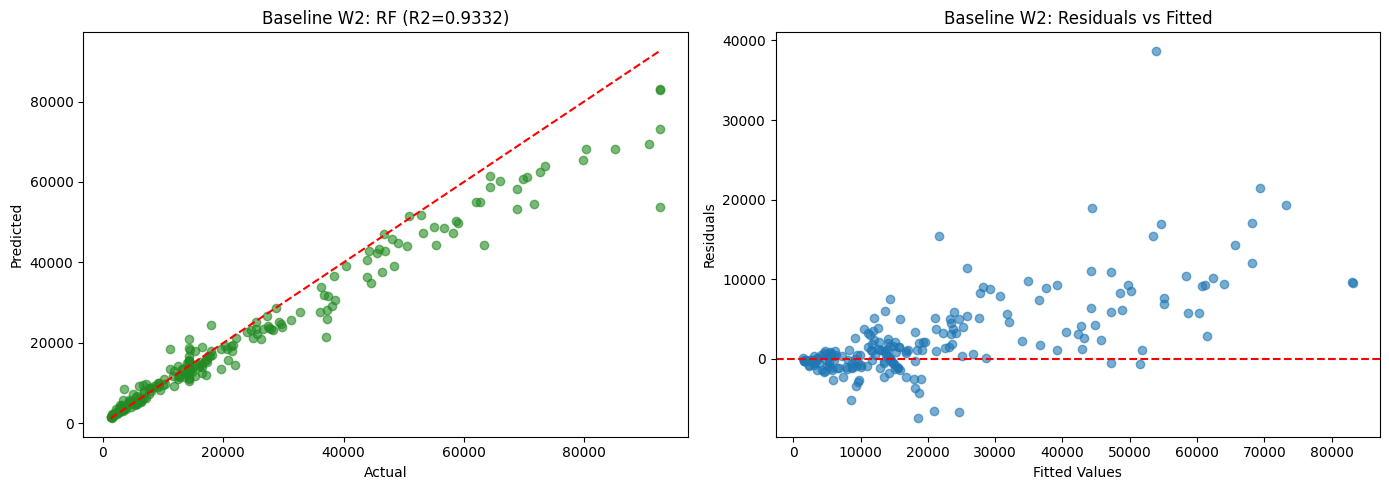

In [8]:
# Baseline plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_baseline, alpha=0.6, color='forestgreen')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Baseline W2: RF (R2={w2_results["R2"]:.4f})')

residuals_bl = y_test - y_pred_baseline
axes[1].scatter(y_pred_baseline, residuals_bl, alpha=0.6)
axes[1].axhline(y=0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted Values'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Baseline W2: Residuals vs Fitted')

plt.tight_layout()
plt.show()

---
## Part B: Piecewise Regression

**Improvements over baseline:**
1. No data leakage — clustering uses train-only country averages
2. Per-cluster feature selection — each cluster picks its own features via RFE
3. IQR clipping on train only — test data stays raw (real-world conditions)
4. No scaler — RF is tree-based, scale-invariant
5. Per-cluster RandomizedSearchCV — custom model per group

### B.1 — Clustering Feature Selection (train only, no leakage)

In [9]:
# Country-level average from TRAIN data only (2017-2020)
# Test year (2021) is NOT used for clustering — no leakage
country_avg = train_df[['Country Name'] + feature_cols].groupby('Country Name').mean().reset_index()
print(f'Countries (from train): {len(country_avg)}')

X_country = country_avg[feature_cols].copy()
X_country = X_country.fillna(X_country.median())

Countries (from train): 216


In [10]:
# VarianceThreshold — source: week07
def remove_low_variance(df_in, threshold=0.01):
    selector = VarianceThreshold(threshold=threshold)
    arr = selector.fit_transform(df_in)
    kept = df_in.columns[selector.get_support()].tolist()
    return pd.DataFrame(arr, columns=kept, index=df_in.index), kept

scaler_vt = StandardScaler()
X_scaled_vt = pd.DataFrame(scaler_vt.fit_transform(X_country), columns=feature_cols, index=X_country.index)
X_vt, vt_kept = remove_low_variance(X_scaled_vt, threshold=0.01)
print(f'After VarianceThreshold: {len(vt_kept)} (from {len(feature_cols)})')

# Correlation filter >0.9 — source: proj1/part2-1
corr_matrix = X_vt.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
cluster_features = [c for c in vt_kept if c not in to_drop]
print(f'After corr filter (>0.9): {len(cluster_features)} (dropped {len(to_drop)})')

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_country[cluster_features])
print(f'Clustering input: {X_cluster_scaled.shape}')

After VarianceThreshold: 116 (from 116)
After corr filter (>0.9): 98 (dropped 18)
Clustering input: (216, 98)


### B.2 — Determine k (Elbow + Silhouette)

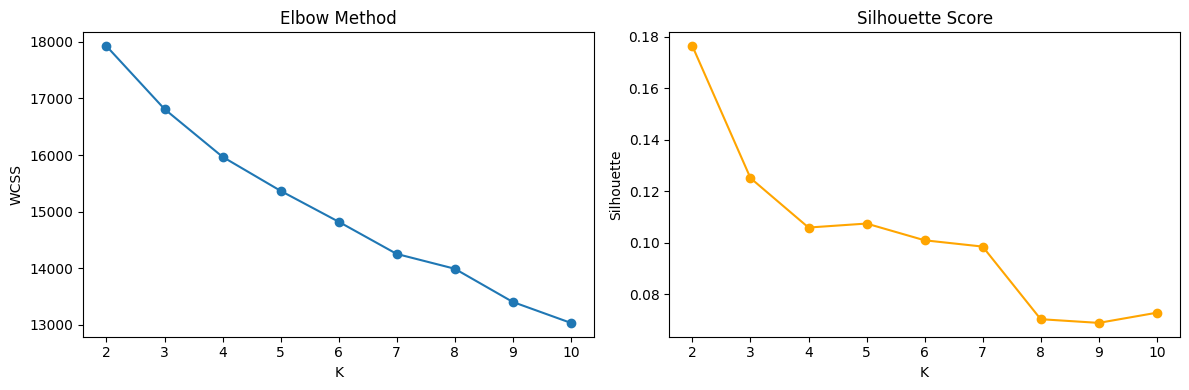

In [11]:
# Elbow + Silhouette — source: proj1/part2-1
wcss = []
sil_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=23)
    labels = kmeans.fit_predict(X_cluster_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, wcss, marker='o')
axes[0].set_xlabel('K'); axes[0].set_ylabel('WCSS'); axes[0].set_title('Elbow Method')
axes[1].plot(k_range, sil_scores, marker='o', color='orange')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette'); axes[1].set_title('Silhouette Score')
plt.tight_layout()
plt.show()

In [12]:
# Evaluation functions — source: proj1/part2-1
def dunn_index(X, labels):
    unique_clusters = np.unique(labels)
    centroids = np.array([X[labels == k].mean(axis=0) for k in unique_clusters])
    inter_cluster_dist = np.min(
        cdist(centroids, centroids)[np.triu_indices(len(unique_clusters), k=1)]
    )
    intra_cluster_dist = max(
        np.max(cdist(X[labels == k], X[labels == k]))
        for k in unique_clusters
    )
    return inter_cluster_dist / intra_cluster_dist

def evaluate_clustering(X, X_clusters):
    silhouette = silhouette_score(X, X_clusters)
    db = davies_bouldin_score(X, X_clusters)
    dunn = dunn_index(X, X_clusters)
    ch = calinski_harabasz_score(X, X_clusters)
    return silhouette, db, dunn, ch

eval_rows = []
for k in k_range:
    km_tmp = KMeans(n_clusters=k, n_init=10, random_state=23)
    lbl_tmp = km_tmp.fit_predict(X_cluster_scaled)
    s, d, du, c = evaluate_clustering(X_cluster_scaled, lbl_tmp)
    eval_rows.append({'k': k, 'Silhouette': round(s, 4), 'Davies-Bouldin': round(d, 4),
                      'Dunn': round(du, 4), 'Calinski-Harabasz': round(c, 2)})

eval_df = pd.DataFrame(eval_rows)
print(eval_df.to_string(index=False))

 k  Silhouette  Davies-Bouldin   Dunn  Calinski-Harabasz
 2      0.1764          2.1105 0.3185              38.74
 3      0.1252          2.3457 0.3088              27.60
 4      0.1059          2.1914 0.2619              23.02
 5      0.1075          2.3970 0.2497              19.92
 6      0.1010          2.0879 0.2933              17.99
 7      0.0985          2.4454 0.2385              16.90
 8      0.0703          2.1749 0.2292              15.25
 9      0.0689          2.3412 0.2190              14.99
10      0.0728          2.1553 0.2403              14.29


In [ ]:
# === SET YOUR K HERE ===
best_k = 5  # <-- change this based on the plots and table above

kmeans_model = KMeans(n_clusters=best_k, n_init=10, random_state=23)
kmeans_labels = kmeans_model.fit_predict(X_cluster_scaled)
country_avg['Cluster'] = kmeans_labels

sil, db, dunn_val, ch = evaluate_clustering(X_cluster_scaled, kmeans_labels)
print(f'k={best_k}: Silhouette={sil:.4f}, DB={db:.4f}, Dunn={dunn_val:.4f}, CH={ch:.2f}')
print(f'\nCluster distribution:')
print(country_avg['Cluster'].value_counts().sort_index())

### B.3 — Cluster Visualizations

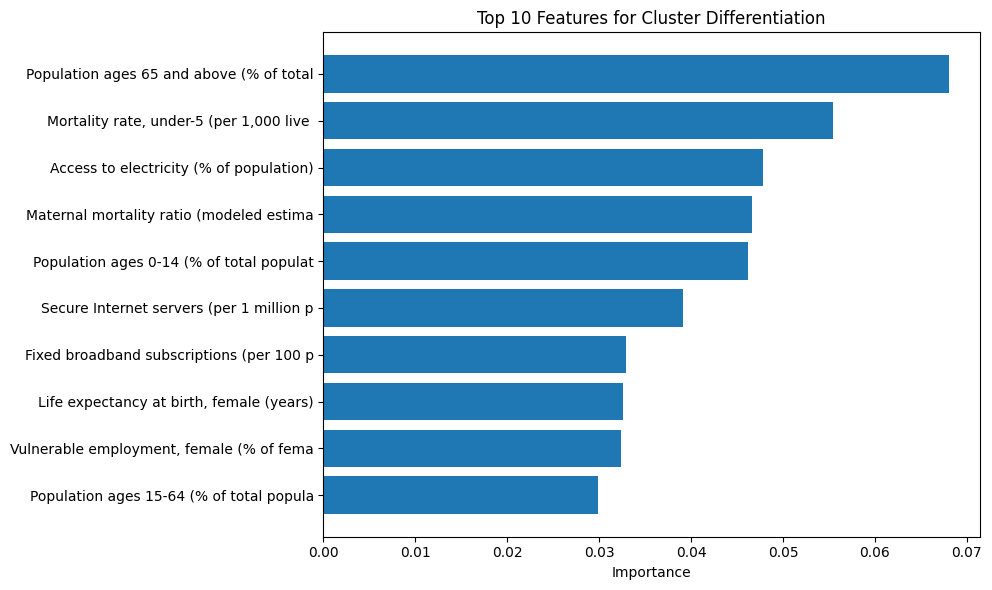

In [14]:
# RF feature importance — source: proj1/part2-1
rf_clf = RandomForestClassifier(n_estimators=100, random_state=23)
rf_clf.fit(X_cluster_scaled, kmeans_labels)

feature_importance_cl = pd.DataFrame({
    'Feature': cluster_features,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=False)

top_10_features = feature_importance_cl.head(10)['Feature'].tolist()

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_cl.head(10)['Feature'].str[:40], feature_importance_cl.head(10)['Importance'])
plt.xlabel('Importance')
plt.title('Top 10 Features for Cluster Differentiation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

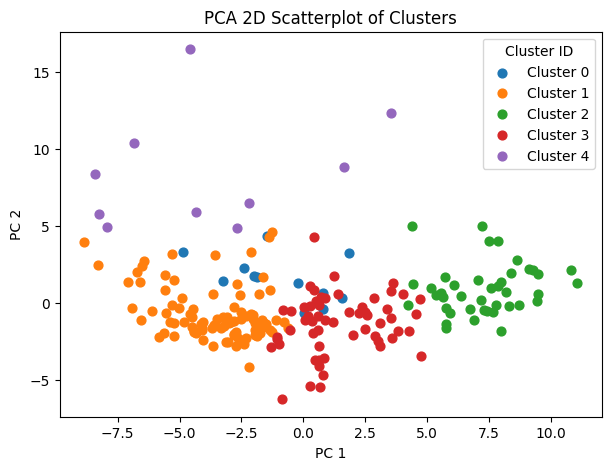

In [15]:
# PCA 2D scatter — source: proj1/part2-1
def create_pca_scatterplot(X_scaled, X_clusters):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    plt.figure(figsize=(7, 5))
    for cluster_id in np.unique(X_clusters):
        idx = X_clusters == cluster_id
        plt.scatter(X_pca[idx, 0], X_pca[idx, 1], s=40, label=f'Cluster {cluster_id}')
    plt.title('PCA 2D Scatterplot of Clusters')
    plt.xlabel('PC 1'); plt.ylabel('PC 2')
    plt.legend(title='Cluster ID')
    plt.show()

create_pca_scatterplot(X_cluster_scaled, kmeans_labels)

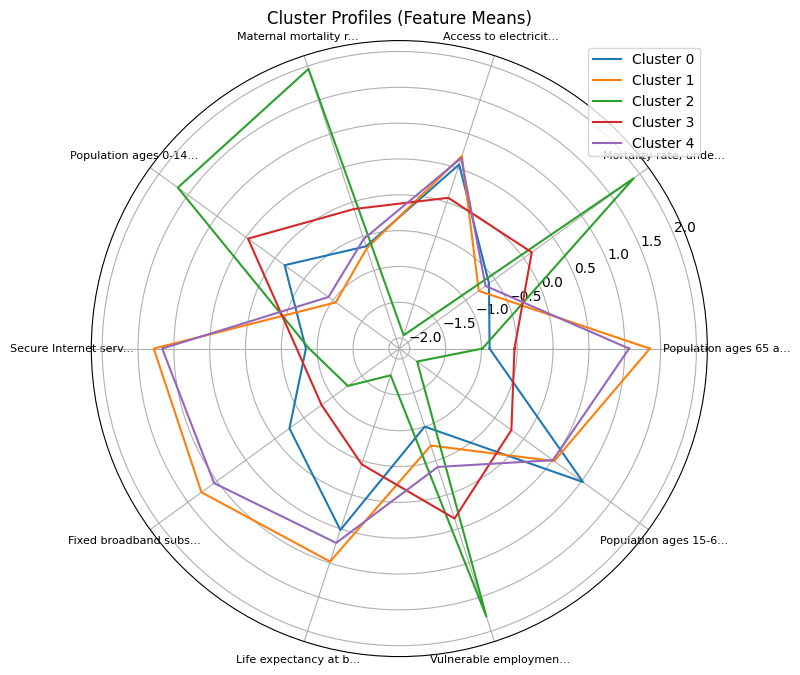

In [16]:
# Radar chart — source: proj1/part2-1
def create_radar_graph(X, X_clusters):
    clustered_df = X.copy()
    clustered_df['Cluster'] = X_clusters
    cluster_means = clustered_df.groupby('Cluster').mean()
    labels = cluster_means.columns
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]
    plt.figure(figsize=(8, 8))
    for i, row in cluster_means.iterrows():
        values = row.tolist() + row.tolist()[:1]
        plt.polar(angles, values, label=f'Cluster {i}')
    plt.xticks(angles[:-1], labels, fontsize=8)
    plt.title('Cluster Profiles (Feature Means)')
    plt.legend()
    plt.show()

cluster_means_raw = pd.DataFrame(X_cluster_scaled, columns=cluster_features)
cluster_means_raw['KMeans_Cluster'] = kmeans_labels
cluster_means_raw = cluster_means_raw.groupby('KMeans_Cluster')[top_10_features].mean()
scaler_radar = StandardScaler()
X_top10_scaled = pd.DataFrame(
    scaler_radar.fit_transform(cluster_means_raw),
    columns=cluster_means_raw.columns, index=cluster_means_raw.index
)
X_top10_scaled.columns = [c[:20] + '...' if len(c) > 20 else c for c in X_top10_scaled.columns]
create_radar_graph(X_top10_scaled, X_top10_scaled.index.values)

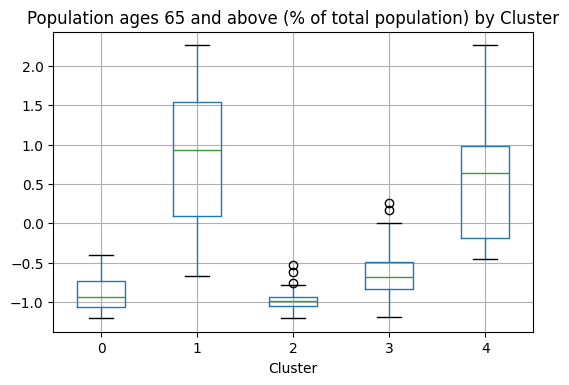

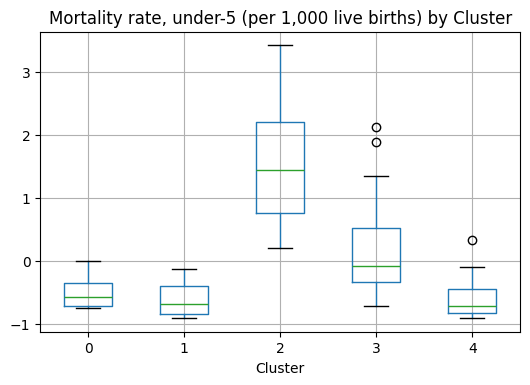

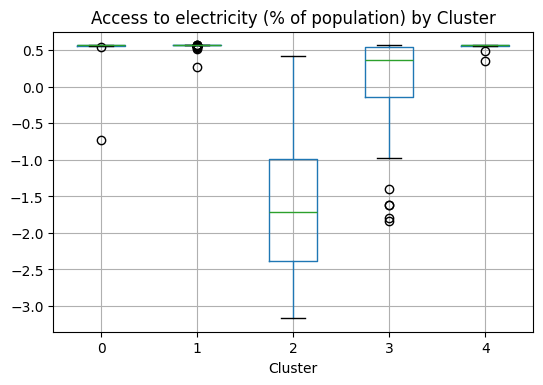

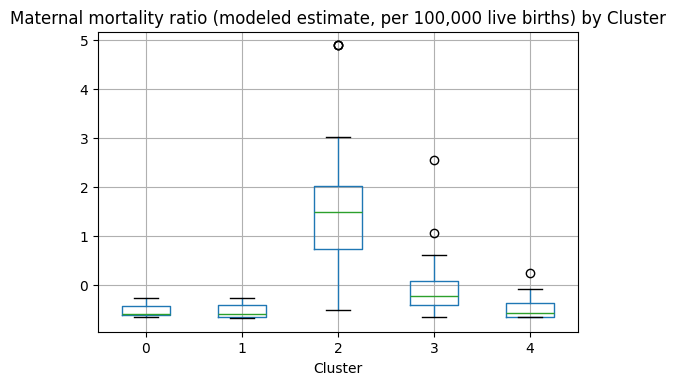

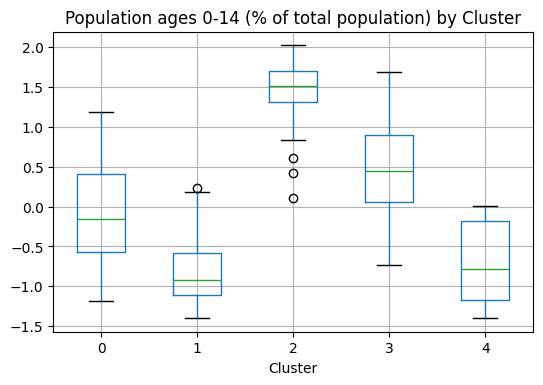

In [17]:
# Boxplots — source: proj1/part2-1
def create_feature_boxplots(X, X_clusters):
    clustered_df = X.copy()
    clustered_df['Cluster'] = X_clusters
    for col in X.columns:
        clustered_df.boxplot(column=col, by='Cluster', figsize=(6, 4))
        plt.title(f'{col} by Cluster')
        plt.suptitle('')
        plt.show()

X_top5 = pd.DataFrame(X_cluster_scaled, columns=cluster_features)[top_10_features[:5]].copy()
create_feature_boxplots(X_top5, kmeans_labels)

In [18]:
# Cluster GNI profile
if target_col in country_avg.columns:
    profile = country_avg.groupby('Cluster')[target_col].agg(['mean','median','count','std'])
    profile.columns = ['Mean GNI', 'Median GNI', 'Count', 'Std GNI']
    print('Cluster Profile (GNI per capita):')
    print(profile.round(0))

### B.4 — Propagate Cluster Labels

In [19]:
# Map cluster labels to year-rows
# Clustering was fit on train-only country averages — no leakage
cluster_map = country_avg.set_index('Country Name')['Cluster'].to_dict()
train_df['Cluster'] = train_df['Country Name'].map(cluster_map)
test_df['Cluster'] = test_df['Country Name'].map(cluster_map)

# Drop unmatched
train_df = train_df.dropna(subset=['Cluster']).copy()
test_df = test_df.dropna(subset=['Cluster']).copy()
train_df['Cluster'] = train_df['Cluster'].astype(int)
test_df['Cluster'] = test_df['Cluster'].astype(int)

print('Train clusters:')
print(train_df['Cluster'].value_counts().sort_index())
print('\nTest clusters:')
print(test_df['Cluster'].value_counts().sort_index())

Train clusters:
Cluster
0     48
1    380
2    164
3    232
4     40
Name: count, dtype: int64

Test clusters:
Cluster
0    12
1    95
2    41
3    58
4    10
Name: count, dtype: int64


### B.5 — Per-Cluster IQR Clipping (TRAIN ONLY)

Test data stays raw — real-world conditions. Source: week02.

In [20]:
# IQR clipping on TRAIN only — test stays untouched
# This preserves real-world shocks (e.g. COVID) in test evaluation
cluster_gni_std = train_df.groupby('Cluster')[target_col].std()
median_std = cluster_gni_std.median()
print('GNI std per cluster:')
print(cluster_gni_std.round(0))

for cid in sorted(train_df['Cluster'].unique()):
    c_train = train_df['Cluster'] == cid
    mult = 1.0 if cluster_gni_std.get(cid, 0) > median_std else 1.5
    clipped = 0

    for col in feature_cols:
        Q1 = train_df.loc[c_train, col].quantile(0.25)
        Q3 = train_df.loc[c_train, col].quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - mult * IQR, Q3 + mult * IQR
        clipped += ((train_df.loc[c_train, col] < lo) | (train_df.loc[c_train, col] > hi)).sum()
        train_df.loc[c_train, col] = train_df.loc[c_train, col].clip(lo, hi)
        # test_df is NOT clipped — stays raw

    tag = 'TIGHT' if mult == 1.0 else 'std'
    print(f'Cluster {cid} [{tag}]: {clipped} train cells clipped (n_train={c_train.sum()})')

print('\nTrain IQR clipping done. Test data untouched.')

GNI std per cluster:
Cluster
0    26217.0
1    20125.0
2     3301.0
3     5058.0
4    19561.0
Name: GNI per capita, PPP (current international $), dtype: float64
Cluster 0 [TIGHT]: 678 train cells clipped (n_train=48)
Cluster 1 [TIGHT]: 6056 train cells clipped (n_train=380)
Cluster 2 [std]: 1284 train cells clipped (n_train=164)
Cluster 3 [std]: 2276 train cells clipped (n_train=232)
Cluster 4 [std]: 248 train cells clipped (n_train=40)

Train IQR clipping done. Test data untouched.


### B.6 — Per-Cluster Model Training

Each cluster gets its OWN RFE feature selection + tuned RF.
Different economies are driven by different factors.

In [ ]:
MIN_TRAIN_SAMPLES = 10

# Raw target — no log-transform (RF is scale-invariant)
y_train_raw = train_df[target_col].values

# Global fallback — no scaler for RF
X_train_global = train_df[feature_cols].values
global_rf = RandomForestRegressor(n_estimators=100, random_state=23)
global_rf.fit(X_train_global, y_train_raw)
global_features = feature_cols

cluster_models = {}
cluster_selected_features = {}
fallback_clusters = []

def train_cluster_model(cid, param_dist, corr_threshold=0.3, n_rfe_select='half', n_iter_base=20):
    """Train a single cluster's model. Customize per cluster as needed."""
    c_mask = train_df['Cluster'] == cid
    X_c_all = train_df.loc[c_mask, feature_cols]
    y_c = train_df.loc[c_mask, target_col].values
    n_train = len(X_c_all)

    is_wide = cluster_gni_std.get(cid, 0) > median_std
    tag = 'wide' if is_wide else 'std'

    if n_train < MIN_TRAIN_SAMPLES:
        print(f'Cluster {cid} [{tag}]: FALLBACK (n={n_train})')
        cluster_models[cid] = None
        cluster_selected_features[cid] = None
        fallback_clusters.append(cid)
        return

    # Step 1: corr filter
    c_corr = X_c_all.corrwith(pd.Series(y_c, index=X_c_all.index)).abs()
    c_corr_feats = c_corr[c_corr >= corr_threshold].index.tolist()
    if len(c_corr_feats) < 3:
        c_corr_feats = c_corr.nlargest(20).index.tolist()

    # Step 2: RFE
    X_rfe = X_c_all[c_corr_feats].values
    if n_rfe_select == 'half':
        n_select = max(3, len(c_corr_feats) // 2)
    else:
        n_select = max(3, min(n_rfe_select, len(c_corr_feats)))
    rf_rfe = RandomForestRegressor(n_estimators=50, random_state=23)
    rfe_c = RFE(estimator=rf_rfe, n_features_to_select=n_select, step=1)
    rfe_c.fit(X_rfe, y_c)
    c_selected = [f for f, s in zip(c_corr_feats, rfe_c.support_) if s]
    if len(c_selected) < 3:
        c_selected = c_corr_feats[:min(20, len(c_corr_feats))]

    cluster_selected_features[cid] = c_selected

    # Step 3: RandomizedSearchCV
    X_c_train = X_c_all[c_selected].values
    cv_folds = min(5, n_train // 2)
    n_iter = min(n_iter_base, n_train)

    search = RandomizedSearchCV(
        RandomForestRegressor(random_state=23),
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring='r2',
        cv=cv_folds,
        n_jobs=-1,
        random_state=23
    )
    search.fit(X_c_train, y_c)

    cluster_models[cid] = search.best_estimator_
    bp = search.best_params_
    print(f'Cluster {cid} [{tag}]: n={n_train}, features={len(c_selected)}, '
          f'cv_R2={search.best_score_:.3f}')
    print(f'  Selected: {[f[:40] for f in c_selected]}')
    print(f'  Best params: n_estimators={bp["n_estimators"]}, max_depth={bp["max_depth"]}, '
          f'min_samples_split={bp["min_samples_split"]}, min_samples_leaf={bp["min_samples_leaf"]}, '
          f'max_features={bp["max_features"]}')

print('Setup done. Run each cluster cell below.')

#### Cluster 0

In [ ]:
# === Cluster 0 — customize params here ===
param_dist_0 = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5],
}
train_cluster_model(cid=0, param_dist=param_dist_0, corr_threshold=0.3, n_rfe_select='half', n_iter_base=20)

#### Cluster 1

In [ ]:
# === Cluster 1 — customize params here ===
param_dist_1 = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5],
}
train_cluster_model(cid=1, param_dist=param_dist_1, corr_threshold=0.3, n_rfe_select='half', n_iter_base=20)

#### Cluster 2

In [ ]:
# === Cluster 2 — customize params here ===
param_dist_2 = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5],
}
train_cluster_model(cid=2, param_dist=param_dist_2, corr_threshold=0.3, n_rfe_select='half', n_iter_base=20)

#### Cluster 3

In [ ]:
# === Cluster 3 — customize params here ===
param_dist_3 = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5],
}
train_cluster_model(cid=3, param_dist=param_dist_3, corr_threshold=0.3, n_rfe_select='half', n_iter_base=20)

#### Cluster 4

In [ ]:
# === Cluster 4 — customize params here ===
param_dist_4 = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5],
}
train_cluster_model(cid=4, param_dist=param_dist_4, corr_threshold=0.3, n_rfe_select='half', n_iter_base=20)

### B.7 — Piecewise Prediction & Evaluation

In [ ]:
# Route each test row to its cluster's model
y_pred_piecewise = np.full(len(test_df), np.nan)

for cid in sorted(test_df['Cluster'].unique()):
    t_mask = test_df['Cluster'] == cid

    if cid in fallback_clusters or cluster_models.get(cid) is None:
        X_t = test_df.loc[t_mask, global_features].values
        y_pred_piecewise[t_mask.values] = global_rf.predict(X_t)
    else:
        c_feats = cluster_selected_features[cid]
        X_t = test_df.loc[t_mask, c_feats].values
        y_pred_piecewise[t_mask.values] = cluster_models[cid].predict(X_t)

print(f'Predictions done. NaN: {np.isnan(y_pred_piecewise).sum()}')

In [23]:
# Per-cluster metrics
y_test_pw = test_df[target_col].values
rows = []
for cid in sorted(test_df['Cluster'].unique()):
    t_mask = test_df['Cluster'] == cid
    y_true_c = test_df.loc[t_mask, target_col].values
    y_pred_c = y_pred_piecewise[t_mask.values]
    n = t_mask.sum()
    note = 'fallback' if cid in fallback_clusters else ''
    n_feats = len(cluster_selected_features.get(cid, [])) if cid not in fallback_clusters else 'global'
    if n >= 2:
        rows.append({'Cluster': cid, 'N_test': n, 'N_features': n_feats,
                     'R2': round(r2_score(y_true_c, y_pred_c), 4),
                     'RMSE': round(np.sqrt(mean_squared_error(y_true_c, y_pred_c)), 2),
                     'MAE': round(mean_absolute_error(y_true_c, y_pred_c), 2),
                     'Note': note})
    else:
        rows.append({'Cluster': cid, 'N_test': n, 'N_features': n_feats,
                     'R2': np.nan, 'RMSE': np.nan, 'MAE': np.nan, 'Note': 'low_n'})

per_cluster_df = pd.DataFrame(rows)
print('Per-Cluster Metrics:')
print(per_cluster_df.to_string(index=False))

Per-Cluster Metrics:
 Cluster  N_test  N_features     R2    RMSE     MAE Note
       0      12          39 0.9660 4785.77 3286.61     
       1      95          21 0.9265 6113.67 4321.67     
       2      41           4 0.9521  727.75  546.86     
       3      58          14 0.7840 2550.58 1618.43     
       4      10          39 0.9098 6387.84 4162.58     


In [24]:
# Overall
valid = ~np.isnan(y_pred_piecewise)
pw_results = {
    'R2': r2_score(y_test_pw[valid], y_pred_piecewise[valid]),
    'RMSE': np.sqrt(mean_squared_error(y_test_pw[valid], y_pred_piecewise[valid])),
    'MAE': mean_absolute_error(y_test_pw[valid], y_pred_piecewise[valid])
}
print(f'Overall Piecewise: R2={pw_results["R2"]:.6f}, RMSE={pw_results["RMSE"]:.2f}, MAE={pw_results["MAE"]:.2f}')

Overall Piecewise: R2=0.957409, RMSE=4631.18, MAE=2814.42


### B.8 — Comparison

In [25]:
comparison = pd.DataFrame([
    {'Model': 'proj1 W1: Corr+RFE+LR (ref)', 'R2': 0.809, 'RMSE': 9811, 'MAE': 7210},
    {'Model': 'Baseline W2: Corr+Lasso+RF', 'R2': round(w2_results['R2'], 4),
     'RMSE': round(w2_results['RMSE'], 2), 'MAE': round(w2_results['MAE'], 2)},
    {'Model': f'Piecewise RF (k={best_k}, per-cluster features)', 'R2': round(pw_results['R2'], 4),
     'RMSE': round(pw_results['RMSE'], 2), 'MAE': round(pw_results['MAE'], 2)},
])
print(comparison.to_string(index=False))
print()
r2_imp = (pw_results['R2'] - w2_results['R2']) / abs(w2_results['R2']) * 100
rmse_imp = (w2_results['RMSE'] - pw_results['RMSE']) / w2_results['RMSE'] * 100
print(f'Improvement: R2 {r2_imp:+.1f}%, RMSE {rmse_imp:+.1f}%')

                                   Model     R2    RMSE     MAE
             proj1 W1: Corr+RFE+LR (ref) 0.8090 9811.00 7210.00
              Baseline W2: Corr+Lasso+RF 0.9332 5800.72 3404.17
Piecewise RF (k=5, per-cluster features) 0.9574 4631.18 2814.42

Improvement: R2 +2.6%, RMSE +20.2%


### B.9 — Visualizations

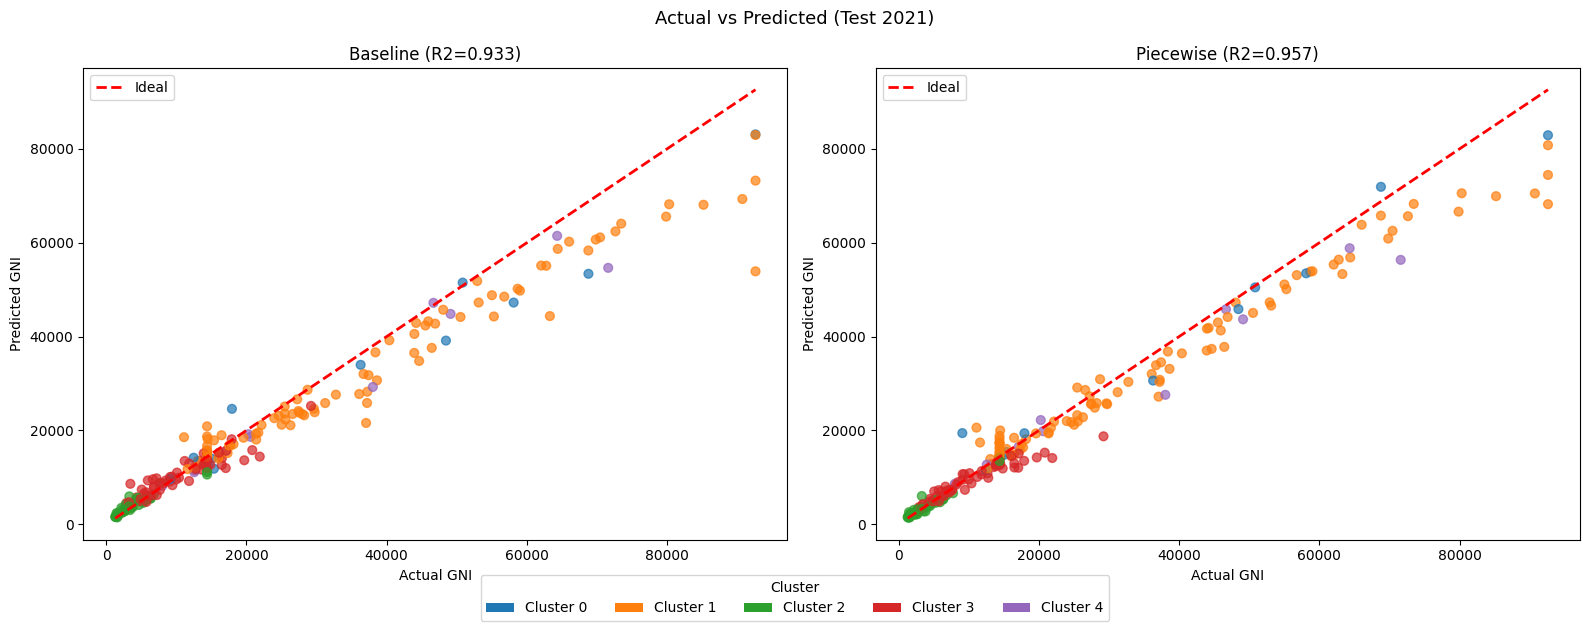

In [26]:
# Actual vs Predicted side-by-side
from matplotlib.patches import Patch

unique_cids = sorted(test_df['Cluster'].unique())
colors_map = {cid: plt.cm.tab10.colors[i] for i, cid in enumerate(unique_cids)}
point_colors = [colors_map[c] for c in test_df['Cluster'].values]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, y_pred, title in [
    (axes[0], y_pred_baseline, f'Baseline (R2={w2_results["R2"]:.3f})'),
    (axes[1], y_pred_piecewise, f'Piecewise (R2={pw_results["R2"]:.3f})'),
]:
    ax.scatter(y_test_pw, y_pred, c=point_colors, alpha=0.7, s=40)
    lo = min(y_test_pw.min(), y_pred.min())
    hi = max(y_test_pw.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=2, label='Ideal')
    ax.set_xlabel('Actual GNI'); ax.set_ylabel('Predicted GNI')
    ax.set_title(title); ax.legend()

legend_el = [Patch(facecolor=colors_map[c], label=f'Cluster {c}') for c in unique_cids]
fig.legend(handles=legend_el, loc='lower center', ncol=len(unique_cids),
           bbox_to_anchor=(0.5, -0.05), title='Cluster')
plt.suptitle('Actual vs Predicted (Test 2021)', fontsize=13)
plt.tight_layout()
plt.show()

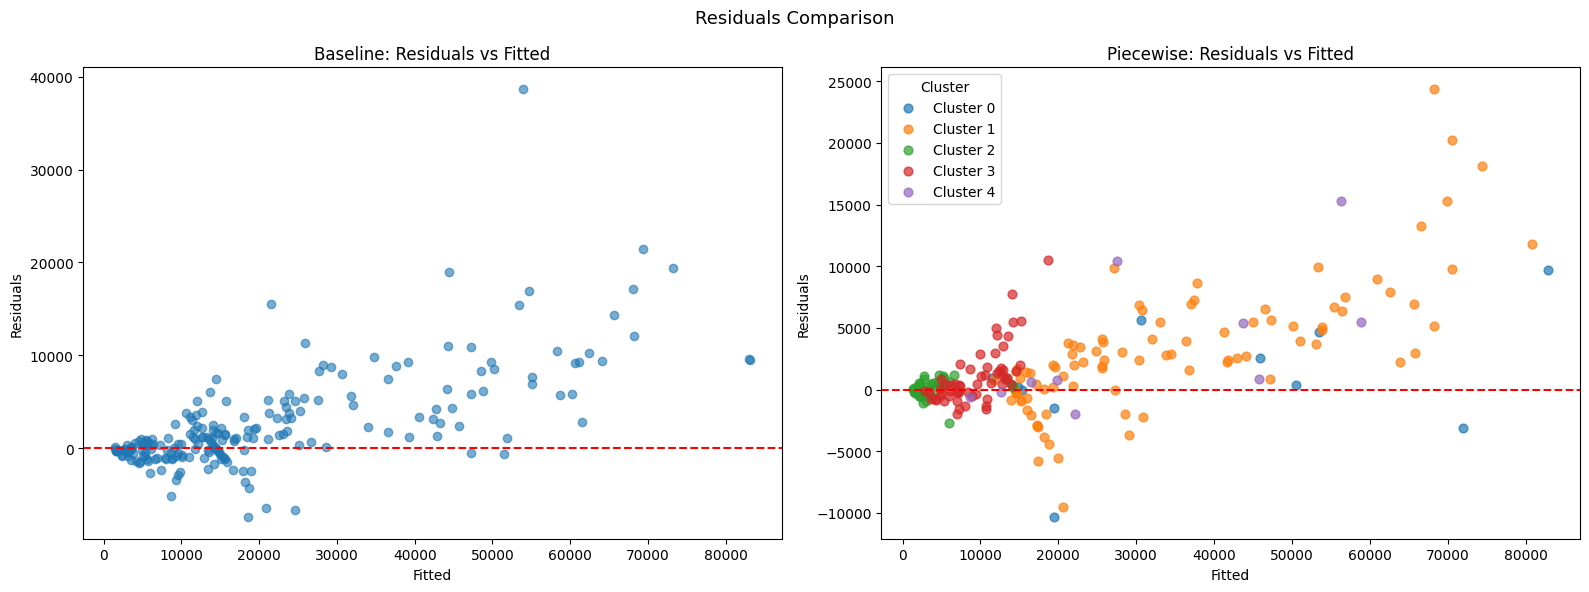

In [27]:
# Residuals side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_pred_baseline, y_test - y_pred_baseline, alpha=0.6)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Baseline: Residuals vs Fitted')

residuals_pw = y_test_pw - y_pred_piecewise
for cid in unique_cids:
    mask = test_df['Cluster'].values == cid
    axes[1].scatter(y_pred_piecewise[mask], residuals_pw[mask],
                    color=colors_map[cid], alpha=0.7, s=40, label=f'Cluster {cid}')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Fitted'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Piecewise: Residuals vs Fitted')
axes[1].legend(title='Cluster')

plt.suptitle('Residuals Comparison', fontsize=13)
plt.tight_layout()
plt.show()

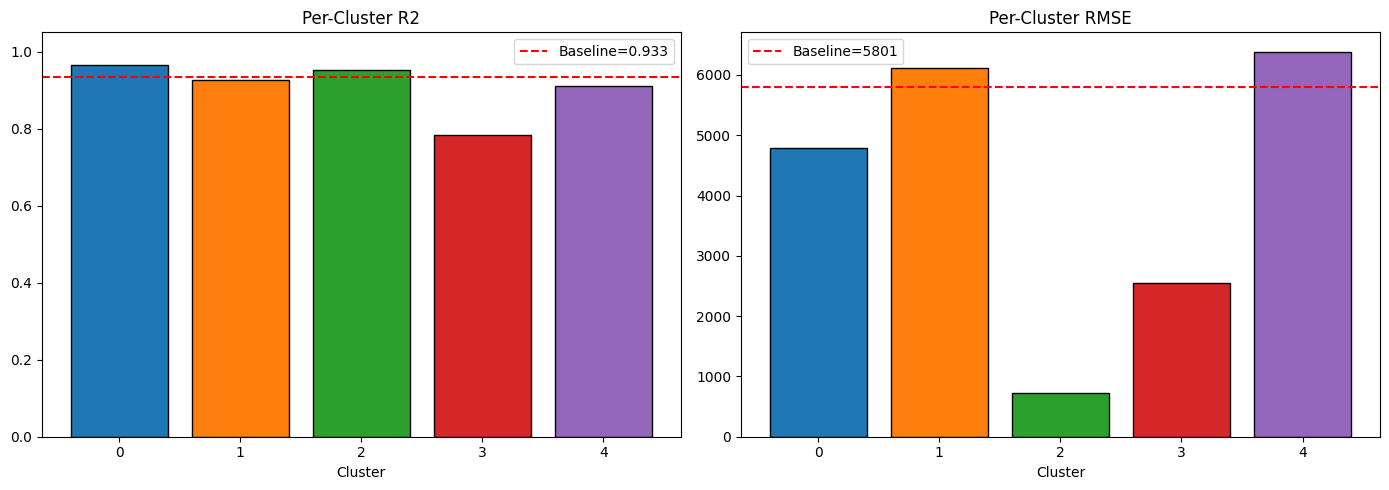

In [28]:
# Per-cluster R2 and RMSE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
valid_rows = per_cluster_df.dropna(subset=['R2'])
bar_c = [colors_map.get(c, 'gray') for c in valid_rows['Cluster']]

axes[0].bar(valid_rows['Cluster'].astype(str), valid_rows['R2'], color=bar_c, edgecolor='black')
axes[0].axhline(w2_results['R2'], color='red', linestyle='--', label=f'Baseline={w2_results["R2"]:.3f}')
axes[0].set_title('Per-Cluster R2'); axes[0].set_xlabel('Cluster')
axes[0].set_ylim(0, 1.05); axes[0].legend()

valid_r = per_cluster_df.dropna(subset=['RMSE'])
bar_r = [colors_map.get(c, 'gray') for c in valid_r['Cluster']]
axes[1].bar(valid_r['Cluster'].astype(str), valid_r['RMSE'], color=bar_r, edgecolor='black')
axes[1].axhline(w2_results['RMSE'], color='red', linestyle='--', label=f'Baseline={w2_results["RMSE"]:.0f}')
axes[1].set_title('Per-Cluster RMSE'); axes[1].set_xlabel('Cluster'); axes[1].legend()

plt.tight_layout()
plt.show()

### B.10 — Summary

**Improvements applied:**
1. **No data leakage** — clustering uses train-only country averages
2. **Per-cluster RFE feature selection** — each cluster picks features relevant to its economy type
3. **IQR clip train only** — test data stays raw (preserves real-world conditions like COVID)
4. **No scaler** — RF is tree-based, scale-invariant
5. **Per-cluster RandomizedSearchCV** — custom model per group

In [29]:
print('=' * 60)
print('FINAL RECAP')
print('=' * 60)
print(comparison.to_string(index=False))
print()
print('Per-Cluster:')
print(per_cluster_df.to_string(index=False))

FINAL RECAP
                                   Model     R2    RMSE     MAE
             proj1 W1: Corr+RFE+LR (ref) 0.8090 9811.00 7210.00
              Baseline W2: Corr+Lasso+RF 0.9332 5800.72 3404.17
Piecewise RF (k=5, per-cluster features) 0.9574 4631.18 2814.42

Per-Cluster:
 Cluster  N_test  N_features     R2    RMSE     MAE Note
       0      12          39 0.9660 4785.77 3286.61     
       1      95          21 0.9265 6113.67 4321.67     
       2      41           4 0.9521  727.75  546.86     
       3      58          14 0.7840 2550.58 1618.43     
       4      10          39 0.9098 6387.84 4162.58     
